In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
from statsmodels.tsa.stattools import adfuller

In [2]:
data = {
    'Date': pd.date_range('2025-01-01', periods=12, freq='ME'),
    'Sales': [100,110,125,140,160,180,200,220,240,260,280,300]
}

df = pd.DataFrame(data)

df.set_index('Date', inplace=True)

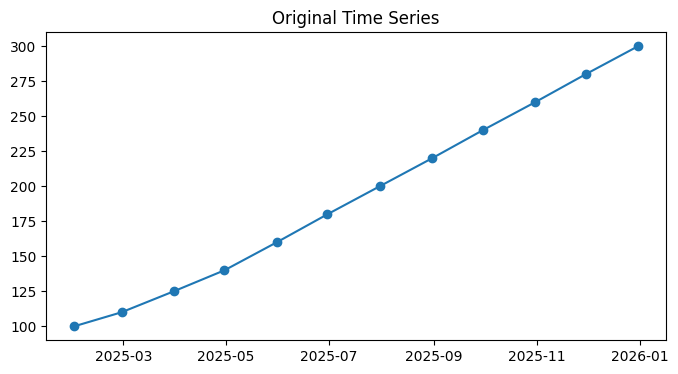

In [3]:
plt.figure(figsize=(8,4))
plt.plot(df.index, df['Sales'],marker='o')
plt.title('Original Time Series')
plt.show()

In [4]:
result = adfuller(df['Sales'])

print('ADF Statistics:',result[0])
print('p-value:',result[1])

ADF Statistics: 0.17821936726920637
p-value: 0.9710131830200759


In [5]:
if result[1]<0.05:
    print('Stationary')
else:
    print('Non-Stationary')

Non-Stationary


In [ ]:
df['sales_diff'] = df['Sales'].diff() # Remove trend using first-order differencing

In [ ]:
print(df['sales_diff']) #Remove the first NaN value

Date
2025-01-31     NaN
2025-02-28    10.0
2025-03-31    15.0
2025-04-30    15.0
2025-05-31    20.0
2025-06-30    20.0
2025-07-31    20.0
2025-08-31    20.0
2025-09-30    20.0
2025-10-31    20.0
2025-11-30    20.0
2025-12-31    20.0
Name: sales_diff, dtype: float64


In [12]:
df_diff = df['sales_diff'].dropna()

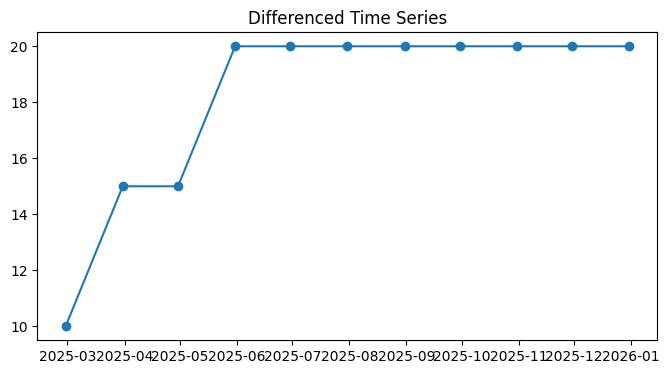

In [13]:
plt.figure(figsize=(8,4))
plt.plot(df_diff, marker='o')
plt.title('Differenced Time Series')
plt.show()

In [14]:
result = adfuller(df_diff)

print("ADF Statistic:", result[0])
print("p-value:", result[1])

ADF Statistic: -4.1952353926806065
p-value: 0.0006712440374490447


c:\Users\MINA\miniconda3\Lib\site-packages\statsmodels\regression\linear_model.py:955: RuntimeWarning: divide by zero encountered in log
  llf = -nobs2*np.log(2*np.pi) - nobs2*np.log(ssr / nobs) - nobs2
